In [1]:
"""
OVERFITTING — cause, effect, and the full toolbox of fixes

Cause: a model with too much capacity relative to the amount/variety
of training data starts memorizing individual examples (including
their noise) instead of learning the general pattern. Small datasets
make this worse since there's less signal to average out over.

Effect: training loss/accuracy keeps improving while validation
loss/accuracy stalls or gets worse — a growing gap between train and
val performance is the signature symptom.

Ways to deal with it fall into two families:

1) INCREASE THE DATA — give the model more to generalize from, so
   memorization becomes harder relative to genuine pattern-learning.
     - Collect/add more rows of real data.
     - Generate more data (data augmentation / synthetic samples) when
       collecting new real data isn't feasible.

2) DECREASE THE MODEL'S EFFECTIVE COMPLEXITY — limit how much the
   model can memorize, forcing it to rely on more general patterns.
     - Dropout: randomly deactivate neurons during training so no
       single neuron/path can be over-relied on.
     - Regularization (L1/L2): penalize large weights in the loss
       function, discouraging the model from fitting noise.
     - Early stopping: halt training once validation performance
       stops improving, before the model starts memorizing.

This notebook focuses on L1 weight regularization specifically — it
compares an unregularized model against a regularized one and inspects
how the weight distributions differ.
"""

"\nOVERFITTING — cause, effect, and the full toolbox of fixes\n\nCause: a model with too much capacity relative to the amount/variety\nof training data starts memorizing individual examples (including\ntheir noise) instead of learning the general pattern. Small datasets\nmake this worse since there's less signal to average out over.\n\nEffect: training loss/accuracy keeps improving while validation\nloss/accuracy stalls or gets worse — a growing gap between train and\nval performance is the signature symptom.\n\nWays to deal with it fall into two families:\n\n1) INCREASE THE DATA — give the model more to generalize from, so\n   memorization becomes harder relative to genuine pattern-learning.\n     - Collect/add more rows of real data.\n     - Generate more data (data augmentation / synthetic samples) when\n       collecting new real data isn't feasible.\n\n2) DECREASE THE MODEL'S EFFECTIVE COMPLEXITY — limit how much the\n   model can memorize, forcing it to rely on more general patte

In [2]:
# Core imports: data generation, plotting, and the Keras building
# blocks needed for both the baseline and regularized models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [3]:
# Generate a small, noisy two-moons dataset — small + noisy is exactly
# the setting where overfitting shows up fastest
X, y = make_moons(100, noise=0.25, random_state=2)

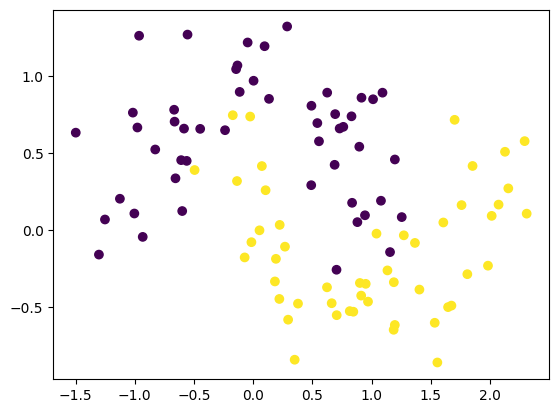

In [4]:
# Visualize the data — confirms a nonlinear decision boundary is needed
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [5]:
"""
BASELINE MODEL — overcapacity (128+128 neurons for 100 points) and no
regularization at all. Expected to overfit; used as the "before".
"""
model1 = Sequential()

model1.add(Dense(128, input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1, activation='sigmoid'))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train for a long time (2000 epochs) with no regularization —
# gives overfitting plenty of room to develop
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split=0.2, verbose=1)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 560ms/step - accuracy: 0.5750 - loss: 0.6431 - val_accuracy: 0.9000 - val_loss: 0.3642
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8375 - loss: 0.4181 - val_accuracy: 0.9000 - val_loss: 0.2163
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8500 - loss: 0.3894 - val_accuracy: 0.9000 - val_loss: 0.2272
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8500 - loss: 0.3790 - val_accuracy: 0.9000 - val_loss: 0.2327
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8500 - loss: 0.3551 - val_accuracy: 0.9000 - val_loss: 0.2491
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8500 - loss: 0.3483 - val_accuracy: 0.9000 - val_loss: 0.2394
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8500 - loss: 0.3282 - val_accuracy: 0.9000 - val_loss: 0.2068
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8500 - loss: 0.3120 - val_accuracy: 0.9000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


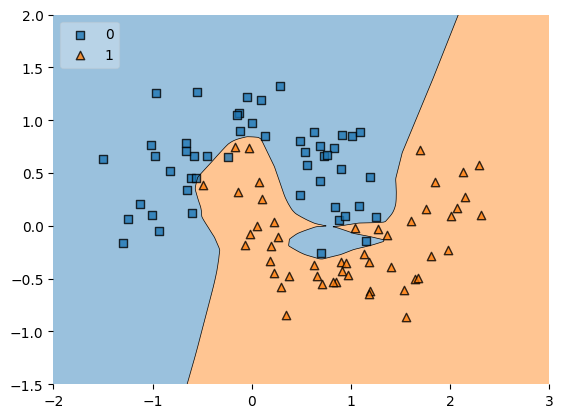

In [7]:
# Decision boundary of the unregularized model — expect a jagged,
# overly complex boundary that hugs individual points
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

In [7]:
# Loss curves — watch for the train/val gap that signals overfitting
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [8]:
"""
FIX — same architecture, but each Dense layer now has an L1 weight
regularizer. L1 penalizes the sum of absolute weight values, pushing
many weights toward exactly zero and discouraging the model from
relying on large, highly specific weights to memorize noise.
"""
model2 = Sequential()

model2.add(Dense(128, input_dim=2, activation="relu",
                  kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",
                  kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1, activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Same training setup as the baseline, for a fair comparison
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split=0.2, verbose=0)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


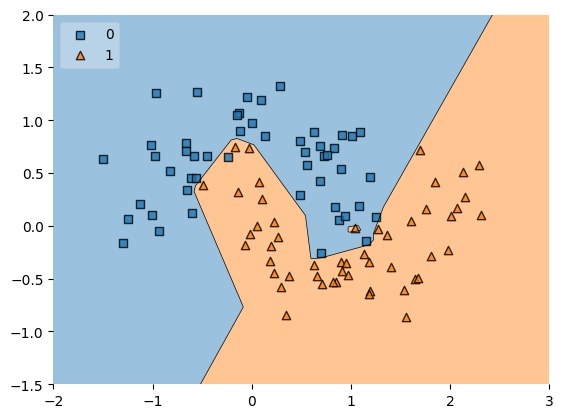

In [10]:
# Decision boundary with L1 regularization — should look smoother,
# since large/erratic weights are penalized
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

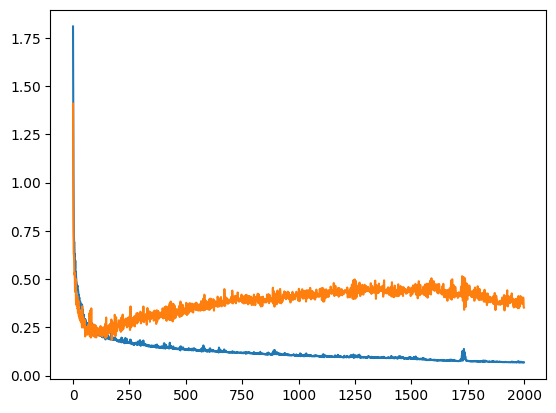

In [11]:
# Loss curves post-regularization — train/val gap should shrink
# compared to the baseline
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [12]:
# Flatten first-layer weights from both models so their magnitude
# distributions can be compared directly
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

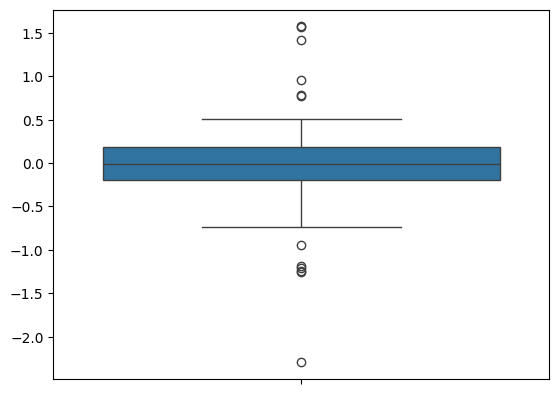

In [13]:
# Weight spread of the unregularized model — expect a wider range,
# including larger-magnitude outlier weights
sns.boxplot(model1_weight_layer1)

In [14]:
# Smallest weight value in the unregularized model
model1_weight_layer1.min()

np.float32(-2.2924762)

In [15]:
# Smallest weight value in the regularized model — should be closer
# to zero, reflecting L1's push toward sparsity
model2_weight_layer1.min()

np.float32(-1.6237558)

/tmp/ipykernel_1299/3935691867.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
/tmp/ipykernel_1299/3935691867.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

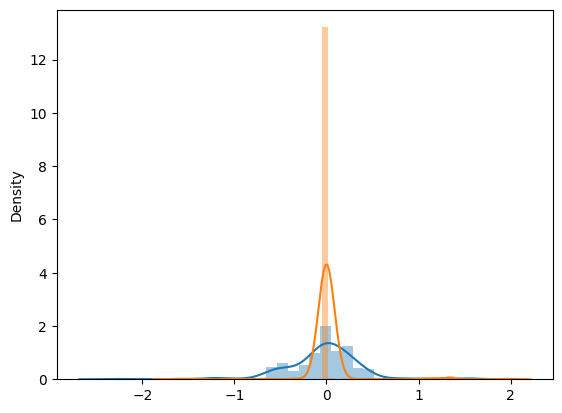

In [16]:
# Overlaid distributions — the regularized model's weights should be
# more tightly clustered around zero than the baseline's
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [17]:
# Raw first-layer weight values of the unregularized model, for
# direct inspection
model1.get_weights()[0].reshape(256)

array([ 4.30069059e-01, -6.03137255e-01,  2.48914540e-01,  2.61524439e-01,
       -7.56213255e-03,  1.91897541e-01, -5.59929430e-01, -3.07032242e-02,
       -4.39774126e-01,  1.84402266e-03,  2.64345229e-01,  1.39136404e-01,
        1.50912568e-01, -1.97274592e-02,  1.82617500e-01,  1.50755301e-01,
       -3.95620316e-01,  4.00494128e-01,  1.92462176e-01, -5.17957687e-01,
       -5.39142549e-01, -2.75546461e-02, -3.19674075e-01,  2.17841286e-02,
       -6.25709966e-02,  2.64567167e-01, -5.91493964e-01,  3.73080410e-02,
       -4.88629073e-01, -4.67844665e-01, -3.35228056e-01, -5.59955597e-01,
        2.11885750e-01,  2.24186853e-01,  2.50206073e-03, -5.20121992e-01,
       -4.30322401e-02,  1.70319930e-01, -4.71140772e-01, -5.24267793e-01,
       -6.31682932e-01, -4.80139613e-01,  1.86635181e-01,  9.94749442e-02,
       -1.62463877e-02,  6.43552244e-02,  2.41173021e-02,  3.17276448e-01,
       -1.91235945e-01,  1.62097011e-02,  2.46002793e-01,  1.09438799e-01,
       -4.39020157e-01, -

In [18]:
"""
SUMMARY — what this notebook did and what we learned

What we did:
  - Generated a small, noisy two-moons dataset (100 points, noise=0.25) —
    deliberately small/noisy to make overfitting easy to trigger.
  - Trained an overcapacity model (128+128 neurons) with no
    regularization for 2000 epochs as a baseline.
  - Trained an identical model but with L1 kernel regularization
    (0.001) added to both hidden layers.
  - Compared the two models' decision boundaries, loss curves, and
    first-layer weight distributions (boxplot, min value, density plot).

What we learned:
  - The unregularized model produced a jagged, overly complex decision
    boundary that hugs individual noisy points — a visual sign of
    overfitting.
  - L1 regularization penalizes the sum of absolute weight values,
    pushing many weights toward zero. This visibly tightened the
    weight distribution (smaller box in the boxplot, min value closer
    to zero, distribution more concentrated around zero) compared to
    the baseline.
  - Constraining weight magnitude translated into a smoother, simpler
    decision boundary — the regularized model relies less on large,
    highly specific weights that would otherwise memorize noise.
  - Together with the dropout notebook, this confirms the "decrease
    complexity" family of overfitting fixes: dropout limits reliance
    on individual neurons, while L1/L2 regularization limits reliance
    on large individual weights — both push the model toward a
    simpler, more generalizable solution.
"""

'\nSUMMARY — what this notebook did and what we learned\n\nWhat we did:\n  - Generated a small, noisy two-moons dataset (100 points, noise=0.25) —\n    deliberately small/noisy to make overfitting easy to trigger.\n  - Trained an overcapacity model (128+128 neurons) with no\n    regularization for 2000 epochs as a baseline.\n  - Trained an identical model but with L1 kernel regularization\n    (0.001) added to both hidden layers.\n  - Compared the two models\' decision boundaries, loss curves, and\n    first-layer weight distributions (boxplot, min value, density plot).\n\nWhat we learned:\n  - The unregularized model produced a jagged, overly complex decision\n    boundary that hugs individual noisy points — a visual sign of\n    overfitting.\n  - L1 regularization penalizes the sum of absolute weight values,\n    pushing many weights toward zero. This visibly tightened the\n    weight distribution (smaller box in the boxplot, min value closer\n    to zero, distribution more concentra